In [107]:
import pandas as pd
df=pd.read_csv("insurance.csv")

In [108]:

# EDA 

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [110]:
df.shape

(1338, 7)

In [111]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [112]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
260,58,female,25.2,0,no,southwest,11837.160
795,27,male,28.5,0,yes,northwest,18310.742
1268,20,female,33.3,0,no,southwest,1880.487
1064,29,female,25.6,4,no,southwest,5708.867
691,47,male,36.2,1,no,southwest,8068.185


In [113]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [114]:
df.duplicated().sum()
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [115]:
df=df.drop_duplicates().copy()
df.duplicated().sum()

np.int64(0)

In [116]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


In [117]:
for col in ["sex", "smoker", "region"]:
    print(col)
    print(df[col].unique())
    print(df[col].value_counts()) # For checking spelling mistakes

sex
['female' 'male']
sex
male      675
female    662
Name: count, dtype: int64
smoker
['yes' 'no']
smoker
no     1063
yes     274
Name: count, dtype: int64
region
['southwest' 'southeast' 'northwest' 'northeast']
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [118]:
df.describe(include="object")

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


In [119]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
# FEATURE CREATION

# Creatig new feature Obese whose bmi > 30
df["obese"] = (df["bmi"]>=30).astype(int)

# Create smoker+obese feature
df["smoker_obese"]=(((df["smoker"]=="yes") & (df["obese"]==1))).astype(int)

# Create age*smoker so that person who has more age and is also smoker sholud be highlighted
temp_smok_binary = (df["smoker"]=="yes").astype(int) #temp convert smoker as
df["age_smoker"] = df["age"]*temp_smok_binary
#Non-smokers get a 0 in this new column.
#Smokers get their actual age (e.g., 45 * 1 = 45).

# Create bmi*smoker same as age*smoker
df["bmi_smoker"] = df["bmi"]*temp_smok_binary




In [121]:

# TRAIN TEST SPLIT

# seperate feature and target
X=df.drop(columns="charges")
Y=df["charges"]

# T-T-S
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [122]:
# Check for missing value
df.isnull().sum()

age             0
sex             0
bmi             0
children        0
smoker          0
region          0
charges         0
obese           0
smoker_obese    0
age_smoker      0
bmi_smoker      0
dtype: int64

In [123]:
# There is no missing value so we move forward
# After handling missing value fix skewness

# Check skewness
skewness=X_train.skew(numeric_only=True)
skewed_feature=skewness[abs(skewness)>0.75].index.tolist()
print(skewed_feature)

['children', 'smoker_obese', 'age_smoker', 'bmi_smoker']


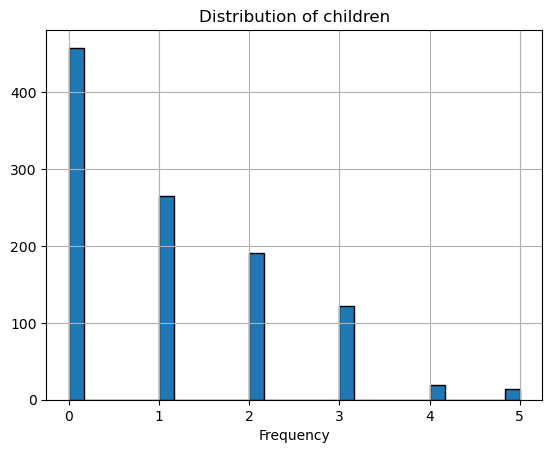

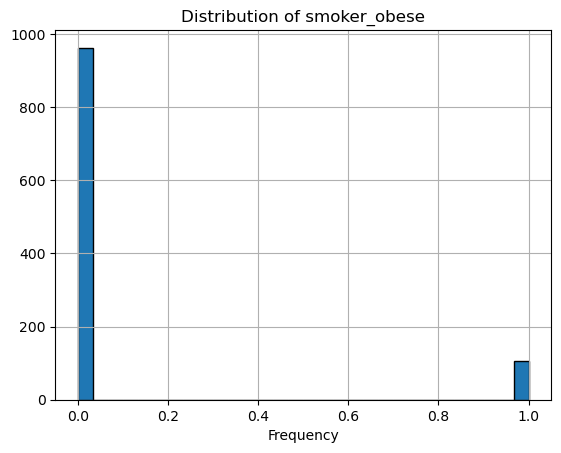

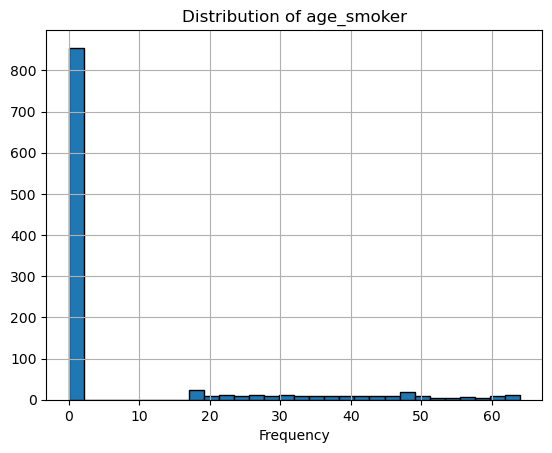

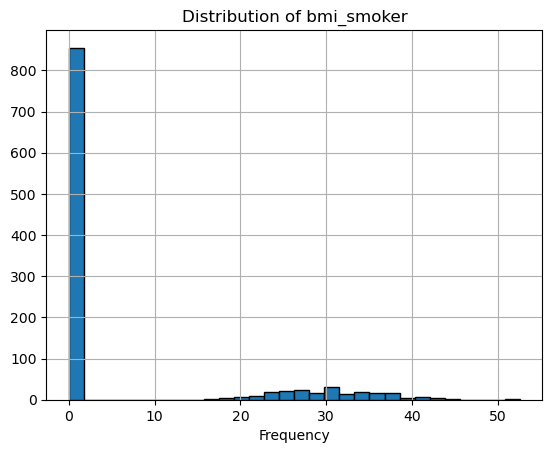

In [124]:
# Check skewness on graph
import matplotlib.pyplot as plt

for feature in skewed_feature:
    X_train[feature].hist(bins=30, edgecolor="black")

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.xlabel("Frequency")

    plt.show()

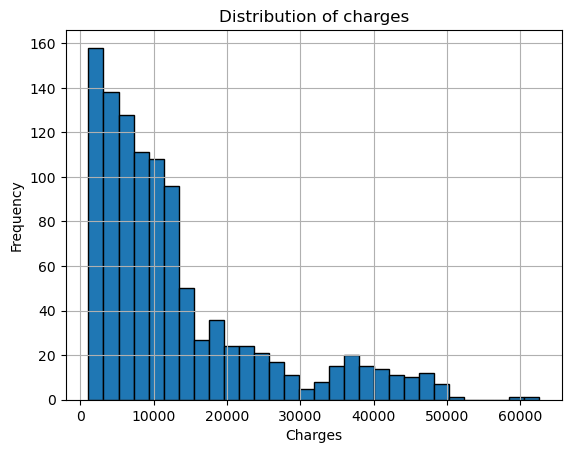

In [125]:

# These are count variable not continuous variable so we should not transform it
# 'smoker_obese', 'age_smoker', 'bmi_smoker' are showed as skewed because most of
# the values are 0 due to many patient as non smoker

# Check the skewness of target var, we should also transform target var if skewed

Y_train.hist(bins=30, edgecolor="black")

plt.title("Distribution of charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

In [127]:

# Handle skewness of target var
# also make sure after prediction we bring it back to normal because when we Train
# on transformed data we will also get transformed output so we have to reverse it

from sklearn.preprocessing import FunctionTransformer
Log_transformer=FunctionTransformer(np.log1p)

Y_train=Log_transformer.fit_transform(Y_train)
Y_test=Log_transformer.transform(Y_test)

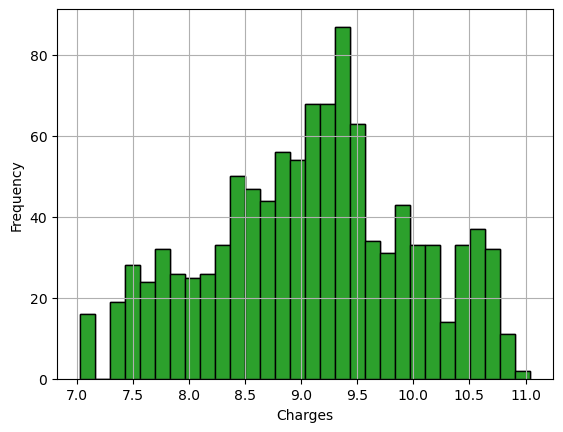

In [131]:
# Distribution after transformation

Y_train.hist(bins=30, edgecolor="black")
plt.title="Distribution of charges"
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()